In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


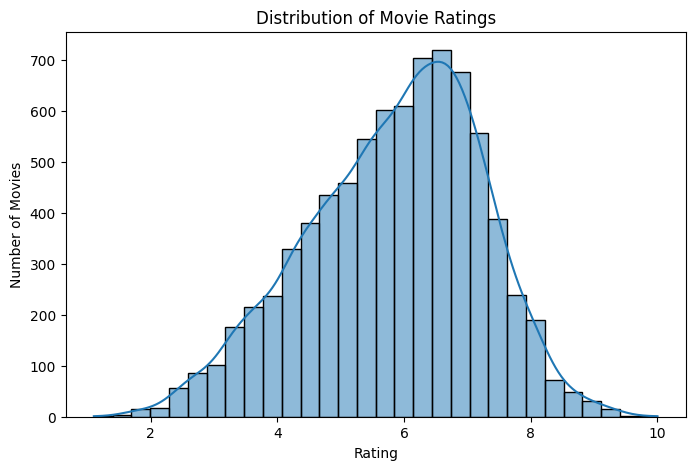

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rating'].dropna(), bins=30, kde=True)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')

plt.show()

In [5]:
print(df['Rating'].describe())

count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


In [6]:
data = df.copy()

# Convert Year to numeric
data['Year'] = data['Year'].astype(str).str.extract(r'(\d{4})')[0]
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

# Convert Duration to numeric
data['Duration'] = data['Duration'].astype(str).str.extract(r'(\d+)')[0]
data['Duration'] = pd.to_numeric(data['Duration'], errors='coerce')

# Convert Votes to numeric
data['Votes'] = data['Votes'].astype(str).str.replace(',', '', regex=False)
data['Votes'] = pd.to_numeric(data['Votes'], errors='coerce')

print(data[['Year', 'Duration', 'Votes']].head())

     Year  Duration  Votes
0     NaN       NaN    NaN
1  2019.0     109.0    8.0
2  2021.0      90.0    NaN
3  2019.0     110.0   35.0
4  2010.0     105.0    NaN


In [7]:
data = data.dropna(subset=['Rating'])

print("Rows after removing missing ratings:", len(data))

Rows after removing missing ratings: 7919


In [8]:
data['Genre_main'] = (
    data['Genre']
    .fillna('Unknown')
    .astype(str)
    .str.split(',')
    .str[0]
    .str.strip()
)

In [9]:
categorical_columns = [
    'Genre_main',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

for col in categorical_columns:
    data[col] = data[col].fillna('Unknown').astype(str)

data['Year'] = data['Year'].fillna(data['Year'].median())
data['Duration'] = data['Duration'].fillna(data['Duration'].median())

print(data.isnull().sum())

Name            0
Year            0
Duration        0
Genre         102
Rating          0
Votes           0
Director        0
Actor 1         0
Actor 2         0
Actor 3         0
Genre_main      0
dtype: int64


In [10]:
genre_rating = (
    data.groupby('Genre_main')['Rating']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(15)
)

print(genre_rating)

                 mean  count
Genre_main                  
Drama        6.172393   2532
Action       5.426019   2306
Comedy       5.811429   1190
Crime        6.016327    343
Romance      5.555556    279
Horror       4.687234    188
Adventure    6.048125    160
Documentary  7.613287    143
Thriller     5.330435    138
Musical      5.984298    121
Unknown      5.999020    102
Biography    6.666667     99
Family       6.107059     85
Mystery      5.807792     77
Animation    5.956164     73


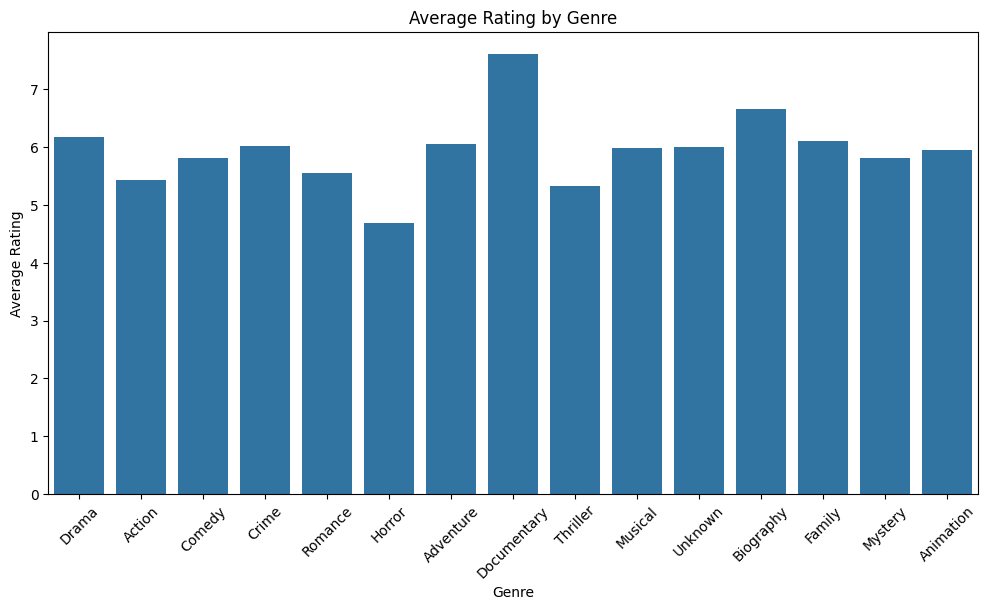

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_rating.index,
    y=genre_rating['mean']
)

plt.xticks(rotation=45)
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')

plt.show()

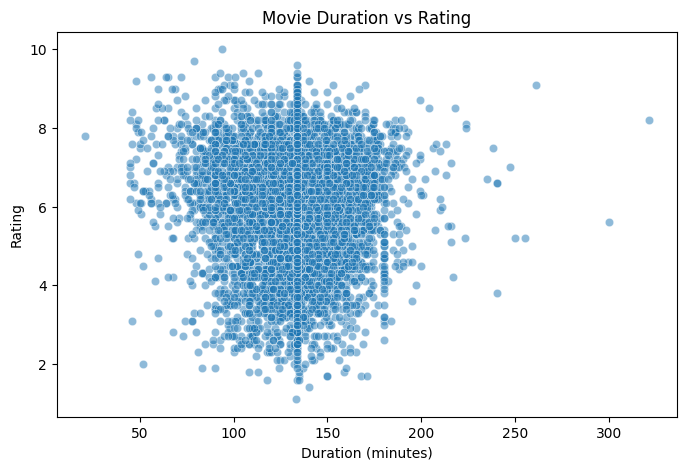

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='Duration',
    y='Rating',
    alpha=0.5
)

plt.title('Movie Duration vs Rating')
plt.xlabel('Duration (minutes)')
plt.ylabel('Rating')

plt.show()

In [13]:
features = [
    'Year',
    'Duration',
    'Genre_main',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

X = data[features]
y = data['Rating']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7919, 7)
y shape: (7919,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6335, 7)
Testing data: (1584, 7)


In [15]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [16]:
from catboost import CatBoostRegressor

In [17]:
categorical_features = [
    'Genre_main',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

for col in categorical_features:
    X_train[col] = X_train[col].fillna('Unknown').astype(str)
    X_test[col] = X_test[col].fillna('Unknown').astype(str)

In [18]:
cat_features = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

model = CatBoostRegressor(
    iterations=700,
    depth=7,
    learning_rate=0.04,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 1.3768175	total: 107ms	remaining: 1m 14s
100:	learn: 1.1580611	total: 3.09s	remaining: 18.3s
200:	learn: 1.1199423	total: 4.89s	remaining: 12.1s
300:	learn: 1.0886053	total: 6.14s	remaining: 8.14s
400:	learn: 1.0645424	total: 7.35s	remaining: 5.48s
500:	learn: 1.0445438	total: 8.52s	remaining: 3.38s
600:	learn: 1.0256414	total: 10.4s	remaining: 1.71s
699:	learn: 1.0063125	total: 13.2s	remaining: 0us


CatBoostRegressor(depth=7, iterations=700, learning_rate=0.04, loss_function='RMSE', random_seed=42, verbose=100)

In [19]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[5.03548218 4.59587687 5.07826978 5.48533788 5.13763714 5.74289726
 5.94408207 5.68111248 6.09859944 6.1175615 ]


In [20]:
comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

comparison.head(10)

,Actual Rating,Predicted Rating
0,3.3,5.035482
1,5.3,4.595877
2,5.7,5.078270
3,7.2,5.485338
4,3.5,5.137637
5,7.2,5.742897
6,3.8,5.944082
7,6.9,5.681112
8,5.2,6.098599
9,7.4,6.117561


In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------------")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("R²   :", round(r2, 3))

Model Performance
-----------------------
MAE  : 0.858
RMSE : 1.108
R²   : 0.339


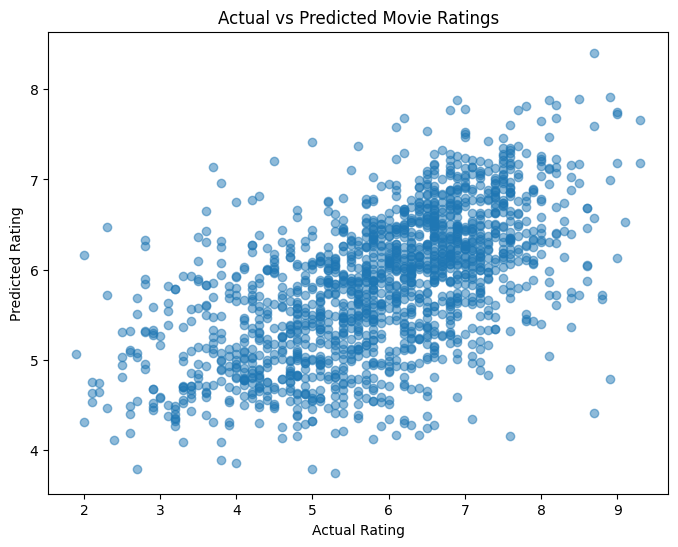

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Movie Ratings')

plt.show()

In [23]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
0        Year   25.611884
2  Genre_main   17.523605
3    Director   16.685337
4     Actor 1   14.839028
1    Duration   11.619296
5     Actor 2    7.324870
6     Actor 3    6.395980


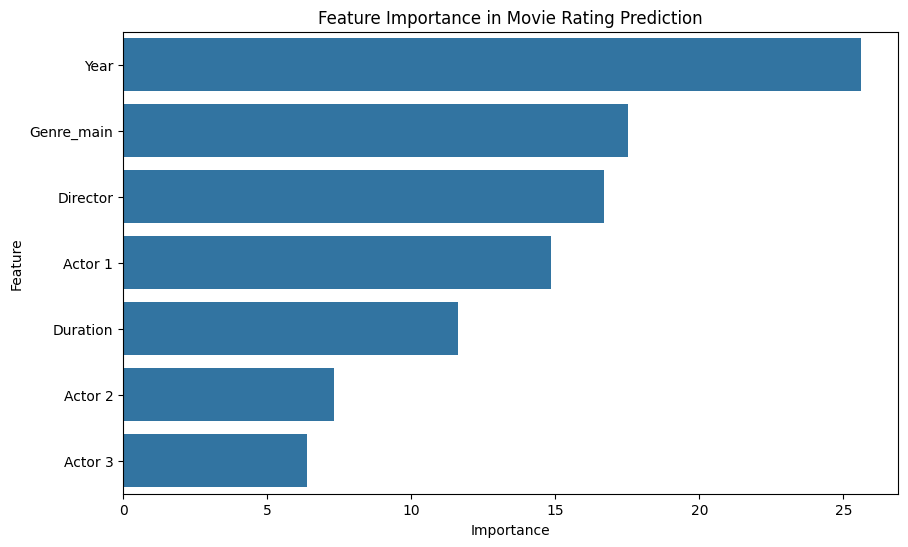

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance in Movie Rating Prediction')

plt.show()

In [25]:
def predict_movie_rating(
    year,
    duration,
    genre,
    director,
    actor1,
    actor2,
    actor3
):

    movie = pd.DataFrame({
        'Year': [year],
        'Duration': [duration],
        'Genre_main': [genre],
        'Director': [director],
        'Actor 1': [actor1],
        'Actor 2': [actor2],
        'Actor 3': [actor3]
    })

    prediction = model.predict(movie)[0]

    return round(prediction, 2)

In [26]:
predicted_rating = predict_movie_rating(
    2024,
    120,
    'Drama',
    'Rajkumar Hirani',
    'Aamir Khan',
    'Anushka Sharma',
    'Boman Irani'
)

print("Predicted Movie Rating:", predicted_rating)

Predicted Movie Rating: 6.7
